In [ ]:
import pandas as pd
import os
# Import our optimized functions
from splade_utils.finetuning_utils import mine_and_score_negatives, train_splade_model, evaluate_model_on_dataset

# CONFIGURATION
BASE_MODEL = "naver/splade-cocondenser-selfdistil" 
TRAIN_DATASET = "scifact"

print(f"Configuration ready.")
print(f"Base Model: {BASE_MODEL}")

c:\Users\curia\miniconda3\envs\splade_final\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration ready.
Base Model: naver/splade-cocondenser-selfdistil


In [ ]:
# PHASE 1: DATA PREPARATION
# We generate training triplets (Query, Positive, Hard Negative) using the base model.
print(f"--- 1. MINING NEGATIVES WITH {BASE_MODEL} ---")

train_triplets = mine_and_score_negatives(
    dataset_name=TRAIN_DATASET, 
    model_name=BASE_MODEL, 
    top_k_negatives=1, 
    batch_size_mining=32
)

print(f"Mining complete. Prepared {len(train_triplets)} triplets.")

--- 1. MINING NEGATIVES WITH naver/splade-cocondenser-selfdistil ---

PHASE 1: SELF-MINING HARD NEGATIVES & DISTILLATION
Loading training set from data/scifact...


  0%|          | 0/5183 [00:00<?, ?it/s]

100%|██████████| 5183/5183 [00:00<00:00, 103329.49it/s]


Loading Model: naver/splade-cocondenser-selfdistil on cuda...


BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


...

Mining negatives (searching for mistakes)...


Mining: 100%|██████████| 809/809 [00:27<00:00, 29.08it/s]


Scoring 919 triplets with Cross-Encoder Teacher...


Batches: 100%|██████████| 15/15 [00:03<00:00,  4.26it/s]


Mining complete. Prepared 919 triplets.


## Analysis on Dense Model (Lambda: 0.0008)

In [ ]:
# Define paths for the FIRST experiment (Low Lambda = Dense/Accurate Model) 
LAMBDA_D = 0.0008   # Document sparsity regularization
LAMBDA_Q = 0.0006   # Query sparsity regularization
MODEL_OUTPUT_DIR = f"models/splade_ft_{TRAIN_DATASET}_lam{LAMBDA_D}"
RESULTS_DIR = f"results/ft_{TRAIN_DATASET}_lam{LAMBDA_D}"

print(f"Model Output Directory: {MODEL_OUTPUT_DIR}")

Model Output Directory: models/2_splade_ft_scifact_lam0.0008


In [ ]:
# TRAINING (Lambda = 0.01)
print(f"\n>>> STARTING TRAINING ON {TRAIN_DATASET} WITH LAMBDA_D = {LAMBDA_D} <<<")

# Launch training (with Early Stopping and Memory Optimizations)
output_path, history = train_splade_model(
    train_triplets=train_triplets,
    base_model_name=BASE_MODEL,
    output_path=MODEL_OUTPUT_DIR,
    lambda_q=LAMBDA_Q,
    lambda_d=LAMBDA_D,
    epochs=5,           
    batch_size=2,        # Optimized for 6GB VRAM
    grad_accum_steps=16, # Simulates effective batch size of 32
    lr=5e-6,
    patience=3
)

print("Training complete. Model saved.")


>>> STARTING TRAINING ON scifact WITH LAMBDA_D = 0.0008 <<<

PHASE 2: TRAINING (Lambda_d=0.0008)
Training on 827 samples, Validating on 92 samples.


c:\Users\curia\miniconda3\envs\splade_final\lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5:   4%|▎         | 15/414 [00:15<01:26,  4.59it/s] c:\Users\curia\miniconda3\envs\splade_final\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch 1/5: 100%|██████████| 414/414 [01:28<00:00,  4.66it/s, Loss=2.3547] 


Epoch 1 finished. Val Loss: 8.7655
New best model found! Saving to models/2_splade_ft_scifact_lam0.0008


Epoch 2/5: 100%|██████████| 414/414 [01:41<00:00,  4.07it/s, Loss=2.5739] 


Epoch 2 finished. Val Loss: 6.9606
New best model found! Saving to models/2_splade_ft_scifact_lam0.0008


...

Epoch 3 finished. Val Loss: 7.4148
No improvement. Patience: 1/3


Epoch 4/5: 100%|██████████| 414/414 [01:26<00:00,  4.81it/s, Loss=1.9076] 


Epoch 4 finished. Val Loss: 6.8124
New best model found! Saving to models/2_splade_ft_scifact_lam0.0008


Epoch 5/5: 100%|██████████| 414/414 [01:37<00:00,  4.25it/s, Loss=3.0040] 


Epoch 5 finished. Val Loss: 6.6885
New best model found! Saving to models/2_splade_ft_scifact_lam0.0008
Training Complete. Best model available at models/2_splade_ft_scifact_lam0.0008
Training complete. Model saved.


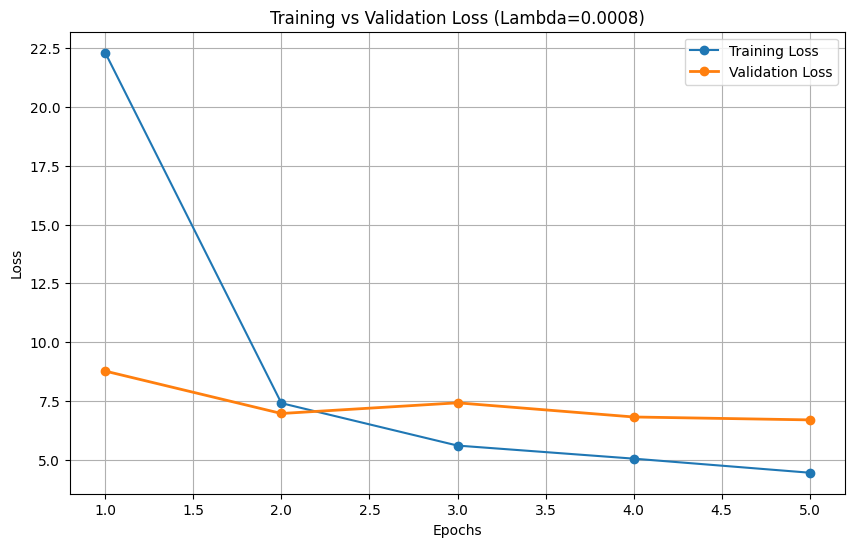

In [5]:
import matplotlib.pyplot as plt

# plot training and validation loss
epochs_list = [h["epoch"] for h in history] # Extract epoch numbers
train_losses = [h["train_loss"] for h in history] # Extract training losses
val_losses = [h["val_loss"] for h in history] # Extract validation losses

# Plotting the losses
plt.figure(figsize=(10, 6))
plt.plot(epochs_list, train_losses, label='Training Loss', marker='o')
plt.plot(epochs_list, val_losses, label='Validation Loss', marker='o', linewidth=2)
plt.title(f'Training vs Validation Loss (Lambda={LAMBDA_D})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# IN-DOMAIN EVALUATION (SCIFACT)
print(f"--- In-Domain Evaluation on {TRAIN_DATASET} ---")

stats_scifact = evaluate_model_on_dataset(
    dataset_name="scifact",
    model_path=MODEL_OUTPUT_DIR,
    output_folder=RESULTS_DIR,
    batch_size=32
)

print("\nResults for SciFact:", stats_scifact)

--- In-Domain Evaluation on scifact ---

PHASE 3: EVALUATION ON SCIFACT
Loading Model from: models/2_splade_ft_scifact_lam0.0008

############################################################
STARTING HYBRID PIPELINE FOR SCIFACT
############################################################

STEP 1: Running SPLADE...

STARTING PIPELINE: SCIFACT | Model: models/2_splade_ft_scifact_lam0.0008
[1/6] Loading data from data/scifact...


100%|██████████| 5183/5183 [00:00<00:00, 108179.37it/s]

Loading Model: models/2_splade_ft_scifact_lam0.0008 on cuda...


[3-4/6] Encoding & Indexing 5183 documents (Chunked)...


Chunk 1: 100%|██████████| 162/162 [03:18<00:00,  1.22s/it]


...

[5/5] Evaluating...

****************************************
BM25 RESULTS FOR SCIFACT
****************************************
nDCG@10: 0.6791
MRR@10:  0.6405
P@10:    0.0900
R@100:   0.9159
R@1k:    0.9683
****************************************

Cleaning memory...
STEP 3: Computing Hybrid Fusion (alpha=0.5)...


100%|██████████| 5183/5183 [00:00<00:00, 113805.84it/s]


Normalizing scores for fusion...


Fusing Scores: 100%|██████████| 300/300 [00:00<00:00, 1473.63it/s]


[Evaluation] Evaluating Hybrid Results...

****************************************
HYBRID RESULTS (SPLADE + BM25) FOR SCIFACT
****************************************
Hybrid nDCG@10: 0.7276
Hybrid MRR@10:  0.6946
****************************************


Results for SciFact: {'Model': 'models/2_splade_ft_scifact_lam0.0008', 'Dataset': 'scifact', 'nDCG@10': 0.70733, 'MRR@10': 0.67841, 'P@10': 0.09267, 'R@100': 0.921, 'R@1k': 0.99, 'Avg_FLOPS': 12.464096726477587, 'Avg_Doc_Sparsity': 194.39340150491992, 'nDCG@10_Hybrid': 0.72759, 'MRR@10_Hybrid': 0.69465}


In [ ]:
# TRANSFER EVALUATION (SCIDOCS)
print(f"--- Transfer Evaluation on SCIDOCS ---")

stats_scidocs = evaluate_model_on_dataset(
    dataset_name="scidocs",
    model_path=MODEL_OUTPUT_DIR,
    output_folder=RESULTS_DIR,
    batch_size=16
)

print("\nResults for SciDocs:", stats_scidocs)

--- Transfer Evaluation on SCIDOCS ---

PHASE 3: EVALUATION ON SCIDOCS
Loading Model from: models/2_splade_ft_scifact_lam0.0008

############################################################
STARTING HYBRID PIPELINE FOR SCIDOCS
############################################################

STEP 1: Running SPLADE...

STARTING PIPELINE: SCIDOCS | Model: models/2_splade_ft_scifact_lam0.0008
[1/6] Loading data from data/scidocs...


100%|██████████| 25657/25657 [00:00<00:00, 30877.63it/s]


Loading Model: models/2_splade_ft_scifact_lam0.0008 on cuda...
[3-4/6] Encoding & Indexing 25657 documents (Chunked)...


Chunk 3: 100%|██████████| 354/354 [02:11<00:00,  2.70it/s]


Index built. Avg Sparsity: 182.85
RAM freed (tracked 25657 docs). Starting CPU Retrieval.
[5/6] Searching 1000 queries...


...

[5/5] Evaluating...

****************************************
BM25 RESULTS FOR SCIDOCS
****************************************
nDCG@10: 0.1534
MRR@10:  0.2693
P@10:    0.0790
R@100:   0.3554
R@1k:    0.5630
****************************************

Cleaning memory...
STEP 3: Computing Hybrid Fusion (alpha=0.5)...


100%|██████████| 25657/25657 [00:00<00:00, 27618.40it/s]


Normalizing scores for fusion...


Fusing Scores: 100%|██████████| 1000/1000 [00:00<00:00, 1131.64it/s]


[Evaluation] Evaluating Hybrid Results...

****************************************
HYBRID RESULTS (SPLADE + BM25) FOR SCIDOCS
****************************************
Hybrid nDCG@10: 0.1677
Hybrid MRR@10:  0.2947
****************************************


Results for SciDocs: {'Model': 'models/2_splade_ft_scifact_lam0.0008', 'Dataset': 'scidocs', 'nDCG@10': 0.15954, 'MRR@10': 0.28488, 'P@10': 0.0815, 'R@100': 0.37942, 'R@1k': 0.60677, 'Avg_FLOPS': 14.124773745956269, 'Avg_Doc_Sparsity': 182.8454223019059, 'nDCG@10_Hybrid': 0.16766, 'MRR@10_Hybrid': 0.29466}


In [ ]:
# GENERALIZATION CHECK (FIQA)
print(f"--- Out-of-Domain Evaluation on FIQA ---")

stats_fiqa = evaluate_model_on_dataset(
    dataset_name="fiqa",
    model_path=MODEL_OUTPUT_DIR,
    output_folder=RESULTS_DIR,
    batch_size=16
)

print("\nResults for FiQA:", stats_fiqa)

--- Out-of-Domain Evaluation on FIQA ---

PHASE 3: EVALUATION ON FIQA
Loading Model from: models/2_splade_ft_scifact_lam0.0008

############################################################
STARTING HYBRID PIPELINE FOR FIQA
############################################################

STEP 1: Running SPLADE...

STARTING PIPELINE: FIQA | Model: models/2_splade_ft_scifact_lam0.0008
[1/6] Loading data from data/fiqa...


100%|██████████| 57638/57638 [00:00<00:00, 200046.42it/s]


Loading Model: models/2_splade_ft_scifact_lam0.0008 on cuda...
[3-4/6] Encoding & Indexing 57638 documents (Chunked)...


Chunk 6: 100%|██████████| 478/478 [03:19<00:00,  2.39it/s]


Index built. Avg Sparsity: 157.80
RAM freed (tracked 57638 docs). Starting CPU Retrieval.
[5/6] Searching 648 queries...


...

[5/5] Evaluating...

****************************************
BM25 RESULTS FOR FIQA
****************************************
nDCG@10: 0.2259
MRR@10:  0.2760
P@10:    0.0644
R@100:   0.5373
R@1k:    0.7508
****************************************

Cleaning memory...
STEP 3: Computing Hybrid Fusion (alpha=0.5)...


100%|██████████| 57638/57638 [00:00<00:00, 192802.42it/s]


Normalizing scores for fusion...


Fusing Scores: 100%|██████████| 648/648 [00:00<00:00, 1025.12it/s]


[Evaluation] Evaluating Hybrid Results...

****************************************
HYBRID RESULTS (SPLADE + BM25) FOR FIQA
****************************************
Hybrid nDCG@10: 0.3140
Hybrid MRR@10:  0.3793
****************************************


Results for FiQA: {'Model': 'models/2_splade_ft_scifact_lam0.0008', 'Dataset': 'fiqa', 'nDCG@10': 0.35061, 'MRR@10': 0.42243, 'P@10': 0.09383, 'R@100': 0.64516, 'R@1k': 0.83815, 'Avg_FLOPS': 10.179419848616675, 'Avg_Doc_Sparsity': 157.7979284499809, 'nDCG@10_Hybrid': 0.31402, 'MRR@10_Hybrid': 0.37932}


## Analysis on Sparse Model (Lambda: 0.008)

In [ ]:
# Define paths for the SECOND experiment (Higher Lambda = Sparser Model) 
LAMBDA_D = 0.008   # Document sparsity regularization
LAMBDA_Q = 0.008   # Query sparsity regularization (Fixed)
MODEL_OUTPUT_DIR = f"models/splade_ft_{TRAIN_DATASET}_lam{LAMBDA_D}"
RESULTS_DIR = f"results/ft_{TRAIN_DATASET}_lam{LAMBDA_D}"

print(f"Model Output Directory: {MODEL_OUTPUT_DIR}")

Model Output Directory: models/2_splade_ft_scifact_lam0.008


In [ ]:
# TRAINING (Lambda = 0.01)
print(f"\n>>> STARTING TRAINING ON {TRAIN_DATASET} WITH LAMBDA_D = {LAMBDA_D} <<<")

# Launch training (with Early Stopping and Memory Optimizations)
output_path, history = train_splade_model(
    train_triplets=train_triplets,
    base_model_name=BASE_MODEL,
    output_path=MODEL_OUTPUT_DIR,
    lambda_q=LAMBDA_Q,
    lambda_d=LAMBDA_D,
    epochs=5,            
    batch_size=2,        # Optimized for 6GB VRAM
    grad_accum_steps=16, # Simulates effective batch size of 32
    lr=5e-6,
    patience=3
)

print("Training complete. Model saved.")


>>> STARTING TRAINING ON scifact WITH LAMBDA_D = 0.008 <<<

PHASE 2: TRAINING (Lambda_d=0.008)
Training on 827 samples, Validating on 92 samples.


c:\Users\curia\miniconda3\envs\splade_final\lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/5:   4%|▎         | 15/414 [00:14<01:18,  5.09it/s] c:\Users\curia\miniconda3\envs\splade_final\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch 1/5: 100%|██████████| 414/414 [01:26<00:00,  4.80it/s, Loss=12.7905]


Epoch 1 finished. Val Loss: 8.7461
New best model found! Saving to models/2_splade_ft_scifact_lam0.008


Epoch 2/5: 100%|██████████| 414/414 [01:26<00:00,  4.76it/s, Loss=9.9544] 


Epoch 2 finished. Val Loss: 7.0990
New best model found! Saving to models/2_splade_ft_scifact_lam0.008


...

Epoch 3 finished. Val Loss: 8.0783
No improvement. Patience: 1/3


Epoch 4/5: 100%|██████████| 414/414 [01:30<00:00,  4.56it/s, Loss=6.2048] 


Epoch 4 finished. Val Loss: 7.2486
No improvement. Patience: 2/3


Epoch 5/5: 100%|██████████| 414/414 [01:31<00:00,  4.55it/s, Loss=2.9991] 


Epoch 5 finished. Val Loss: 7.2546
No improvement. Patience: 3/3
Early stopping triggered to prevent overfitting.
Training Complete. Best model available at models/2_splade_ft_scifact_lam0.008
Training complete. Model saved.


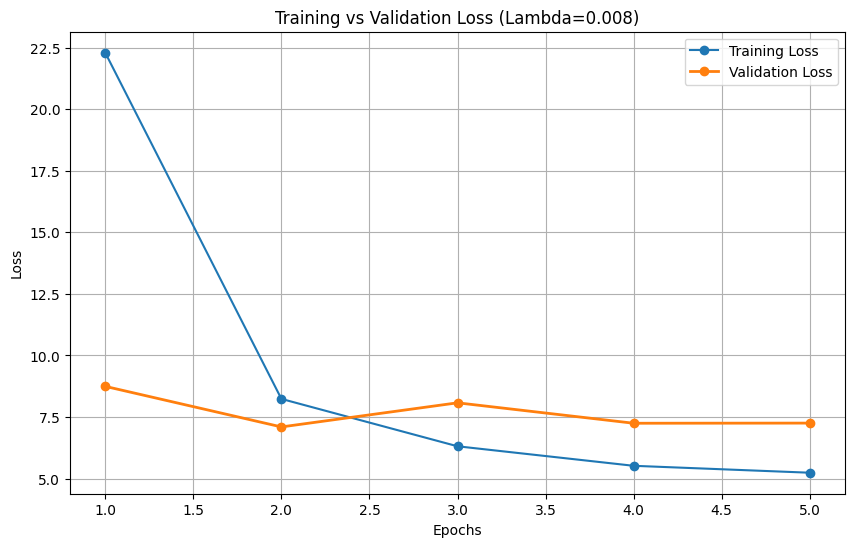

In [11]:
import matplotlib.pyplot as plt

# plot training and validation loss
epochs_list = [h["epoch"] for h in history] # Extract epoch numbers
train_losses = [h["train_loss"] for h in history] # Extract training losses
val_losses = [h["val_loss"] for h in history] # Extract validation losses

# Plotting the losses
plt.figure(figsize=(10, 6))
plt.plot(epochs_list, train_losses, label='Training Loss', marker='o')
plt.plot(epochs_list, val_losses, label='Validation Loss', marker='o', linewidth=2)
plt.title(f'Training vs Validation Loss (Lambda={LAMBDA_D})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# IN-DOMAIN EVALUATION (SCIFACT)
print(f"--- In-Domain Evaluation on {TRAIN_DATASET} ---")

stats_scifact = evaluate_model_on_dataset(
    dataset_name="scifact",
    model_path=MODEL_OUTPUT_DIR,
    output_folder=RESULTS_DIR,
    batch_size=32
)

print("\nResults for SciFact:", stats_scifact)

--- In-Domain Evaluation on scifact ---

PHASE 3: EVALUATION ON SCIFACT
Loading Model from: models/2_splade_ft_scifact_lam0.008

############################################################
STARTING HYBRID PIPELINE FOR SCIFACT
############################################################

STEP 1: Running SPLADE...

STARTING PIPELINE: SCIFACT | Model: models/2_splade_ft_scifact_lam0.008
[1/6] Loading data from data/scifact...


  0%|          | 0/5183 [00:00<?, ?it/s]

100%|██████████| 5183/5183 [00:00<00:00, 78251.32it/s]

Loading Model: models/2_splade_ft_scifact_lam0.008 on cuda...


[3-4/6] Encoding & Indexing 5183 documents (Chunked)...


...

[5/5] Evaluating...

****************************************
BM25 RESULTS FOR SCIFACT
****************************************
nDCG@10: 0.6791
MRR@10:  0.6405
P@10:    0.0900
R@100:   0.9159
R@1k:    0.9683
****************************************

Cleaning memory...
STEP 3: Computing Hybrid Fusion (alpha=0.5)...


100%|██████████| 5183/5183 [00:00<00:00, 112686.75it/s]


Normalizing scores for fusion...


Fusing Scores: 100%|██████████| 300/300 [00:00<00:00, 1317.61it/s]


[Evaluation] Evaluating Hybrid Results...

****************************************
HYBRID RESULTS (SPLADE + BM25) FOR SCIFACT
****************************************
Hybrid nDCG@10: 0.7254
Hybrid MRR@10:  0.6902
****************************************


Results for SciFact: {'Model': 'models/2_splade_ft_scifact_lam0.008', 'Dataset': 'scifact', 'nDCG@10': 0.69991, 'MRR@10': 0.66852, 'P@10': 0.09233, 'R@100': 0.93033, 'R@1k': 0.99333, 'Avg_FLOPS': 9.137903402148048, 'Avg_Doc_Sparsity': 162.2934593864557, 'nDCG@10_Hybrid': 0.72536, 'MRR@10_Hybrid': 0.69024}


In [ ]:
# TRANSFER EVALUATION (SCIDOCS)
print(f"--- Transfer Evaluation on SCIDOCS ---")

stats_scidocs = evaluate_model_on_dataset(
    dataset_name="scidocs",
    model_path=MODEL_OUTPUT_DIR,
    output_folder=RESULTS_DIR,
    batch_size=16
)

print("\nResults for SciDocs:", stats_scidocs)

--- Transfer Evaluation on SCIDOCS ---

PHASE 3: EVALUATION ON SCIDOCS
Loading Model from: models/2_splade_ft_scifact_lam0.008

############################################################
STARTING HYBRID PIPELINE FOR SCIDOCS
############################################################

STEP 1: Running SPLADE...

STARTING PIPELINE: SCIDOCS | Model: models/2_splade_ft_scifact_lam0.008
[1/6] Loading data from data/scidocs...


100%|██████████| 25657/25657 [00:00<00:00, 29506.94it/s]


Loading Model: models/2_splade_ft_scifact_lam0.008 on cuda...
[3-4/6] Encoding & Indexing 25657 documents (Chunked)...


Chunk 3: 100%|██████████| 354/354 [02:09<00:00,  2.73it/s]


Index built. Avg Sparsity: 153.87
RAM freed (tracked 25657 docs). Starting CPU Retrieval.
[5/6] Searching 1000 queries...


...

[5/5] Evaluating...

****************************************
BM25 RESULTS FOR SCIDOCS
****************************************
nDCG@10: 0.1534
MRR@10:  0.2693
P@10:    0.0790
R@100:   0.3554
R@1k:    0.5630
****************************************

Cleaning memory...
STEP 3: Computing Hybrid Fusion (alpha=0.5)...


100%|██████████| 25657/25657 [00:01<00:00, 24675.30it/s]


Normalizing scores for fusion...


Fusing Scores: 100%|██████████| 1000/1000 [00:00<00:00, 1030.39it/s]


[Evaluation] Evaluating Hybrid Results...

****************************************
HYBRID RESULTS (SPLADE + BM25) FOR SCIDOCS
****************************************
Hybrid nDCG@10: 0.1675
Hybrid MRR@10:  0.2916
****************************************


Results for SciDocs: {'Model': 'models/2_splade_ft_scifact_lam0.008', 'Dataset': 'scidocs', 'nDCG@10': 0.16066, 'MRR@10': 0.28614, 'P@10': 0.0824, 'R@100': 0.38227, 'R@1k': 0.6089, 'Avg_FLOPS': 10.473107105273415, 'Avg_Doc_Sparsity': 153.86526094243285, 'nDCG@10_Hybrid': 0.16746, 'MRR@10_Hybrid': 0.29159}


In [ ]:
# GENERALIZATION CHECK (FIQA)
print(f"--- Out-of-Domain Evaluation on FIQA ---")

stats_fiqa = evaluate_model_on_dataset(
    dataset_name="fiqa",
    model_path=MODEL_OUTPUT_DIR,
    output_folder=RESULTS_DIR,
    batch_size=16
)

print("\nResults for FiQA:", stats_fiqa)

--- Out-of-Domain Evaluation on FIQA ---

PHASE 3: EVALUATION ON FIQA
Loading Model from: models/2_splade_ft_scifact_lam0.008

############################################################
STARTING HYBRID PIPELINE FOR FIQA
############################################################

STEP 1: Running SPLADE...

STARTING PIPELINE: FIQA | Model: models/2_splade_ft_scifact_lam0.008
[1/6] Loading data from data/fiqa...


100%|██████████| 57638/57638 [00:00<00:00, 181776.36it/s]


Loading Model: models/2_splade_ft_scifact_lam0.008 on cuda...
[3-4/6] Encoding & Indexing 57638 documents (Chunked)...


Chunk 6: 100%|██████████| 478/478 [03:21<00:00,  2.37it/s]


Index built. Avg Sparsity: 137.61
RAM freed (tracked 57638 docs). Starting CPU Retrieval.
[5/6] Searching 648 queries...


...

[5/5] Evaluating...

****************************************
BM25 RESULTS FOR FIQA
****************************************
nDCG@10: 0.2259
MRR@10:  0.2760
P@10:    0.0644
R@100:   0.5373
R@1k:    0.7508
****************************************

Cleaning memory...
STEP 3: Computing Hybrid Fusion (alpha=0.5)...


100%|██████████| 57638/57638 [00:00<00:00, 160973.93it/s]


Normalizing scores for fusion...


Fusing Scores: 100%|██████████| 648/648 [00:00<00:00, 948.01it/s]


[Evaluation] Evaluating Hybrid Results...

****************************************
HYBRID RESULTS (SPLADE + BM25) FOR FIQA
****************************************
Hybrid nDCG@10: 0.3127
Hybrid MRR@10:  0.3780
****************************************


Results for FiQA: {'Model': 'models/2_splade_ft_scifact_lam0.008', 'Dataset': 'fiqa', 'nDCG@10': 0.35024, 'MRR@10': 0.42022, 'P@10': 0.09522, 'R@100': 0.63742, 'R@1k': 0.83887, 'Avg_FLOPS': 8.133662543229581, 'Avg_Doc_Sparsity': 137.61426489468752, 'nDCG@10_Hybrid': 0.31274, 'MRR@10_Hybrid': 0.37798}
